In [1]:
import yaml
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from matplotlib.ticker import MaxNLocator
from collections import defaultdict
%matplotlib inline


In [16]:

# ── Palette ──────────────────────────────────────────────────────────────────
C_DET   = '#2ECC71'   # detected
C_BEL   = '#E74C3C'   # below threshold
C_NOB   = '#F39C12'   # no blobs
C_IDX2  = '#3498DB'   # spectral index 2
C_IDX3  = '#E67E22'   # spectral index 3
BG      = '#0D1117'
FG      = '#E8EDF3'
GRID    = '#1E2733'
SPINE   = '#2C3E50'

plt.rcParams.update({
    'figure.facecolor':  BG,
    'axes.facecolor':    BG,
    'axes.edgecolor':    SPINE,
    'axes.labelcolor':   FG,
    'axes.titlecolor':   FG,
    'text.color':        FG,
    'xtick.color':       FG,
    'ytick.color':       FG,
    'grid.color':        GRID,
    'grid.linewidth':    0.6,
    'font.family':       'monospace',
    'axes.titlesize':    11,
    'axes.labelsize':    9,
    'xtick.labelsize':   8,
    'ytick.labelsize':   8,
    'legend.fontsize':   8,
    'legend.facecolor':  SPINE,
    'legend.edgecolor':  GRID,
})


In [17]:

# ══════════════════════════════════════════════════════════════════════════════
# Load YAML
# ══════════════════════════════════════════════════════════════════════════════
with open('/lustre/hawcz01/scratch/userspace/rbabu/astroimage/AstroImageDetection/results/results0-50.yaml') as f:
    raw = yaml.safe_load(f)

# ── Flatten into a list of records ────────────────────────────────────────────
records = []
for fname, v in raw.items():
    r = dict(v)
    r['filename'] = fname
    r['n_detected'] = (len(v['detected_sources'])
                       if v.get('detected_sources') else 0)
    records.append(r)

# ── Convenience sub-sets ──────────────────────────────────────────────────────
det   = [r for r in records if r['status'] == 'detected']
below = [r for r in records if r['status'] == 'below_threshold']
nob   = [r for r in records if r['status'] == 'no_blobs']

# group by spectral index
idx2 = [r for r in records if r['spectral_index'] == 2.0]
idx3 = [r for r in records if r['spectral_index'] == 3.0]

# all unique flux fractions, sorted
all_ff = sorted(set(r['flux_fraction'] for r in records))

# detected blobs flat list
blobs = []
for r in det:
    for b in r['detected_sources']:
        blobs.append({**b,
                      'flux_fraction': r['flux_fraction'],
                      'true_extension': r['true_extension'],
                      'spectral_index': r['spectral_index']})

true_ra  = 83.61
true_dec = 22.0


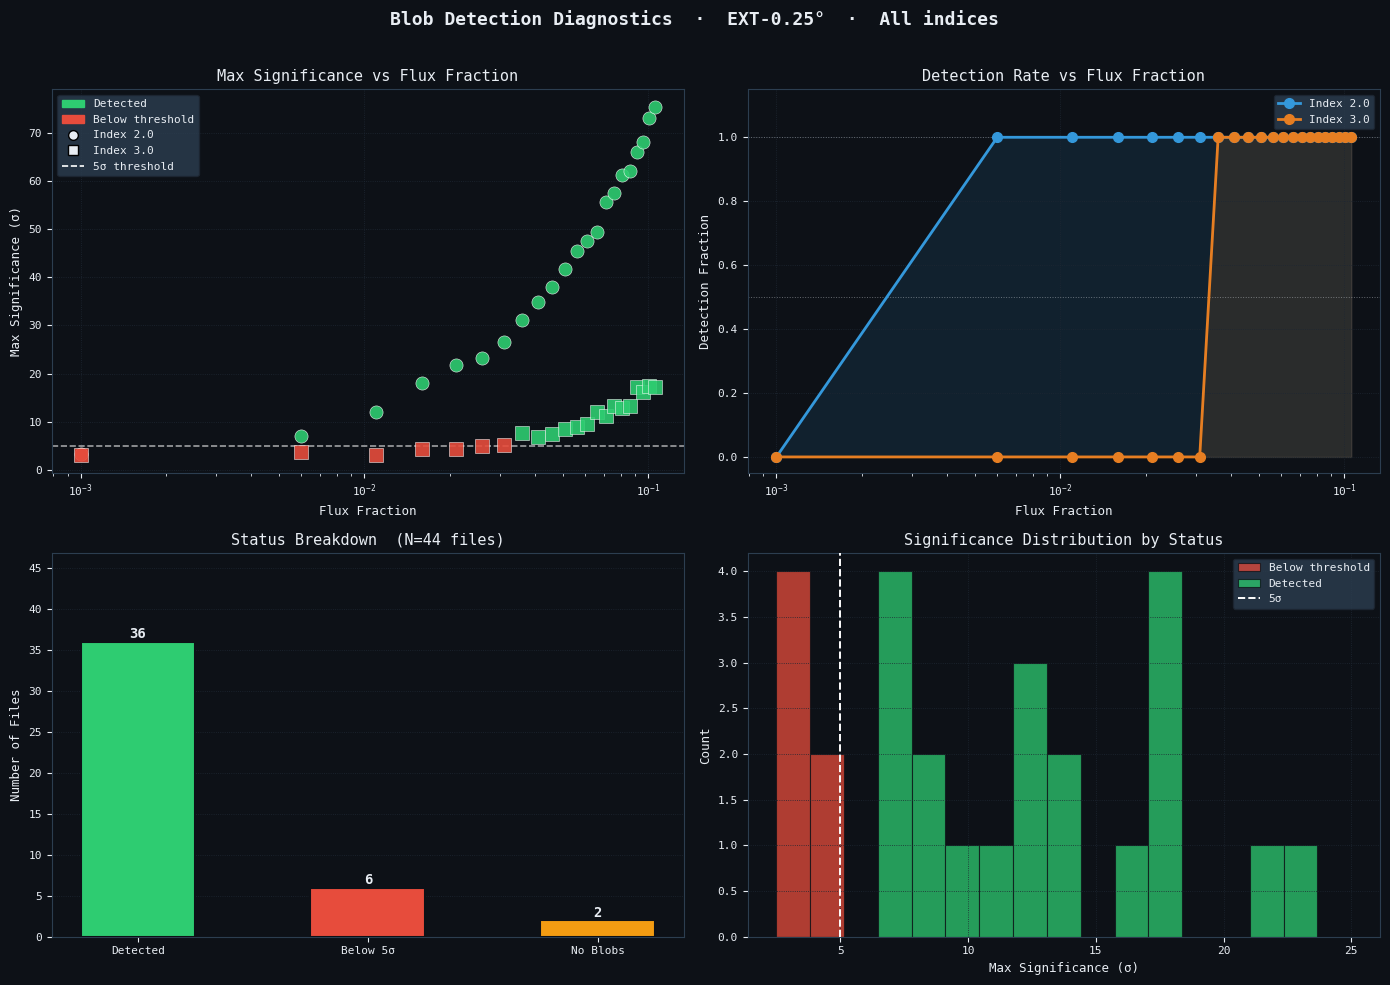

Fig 1 saved


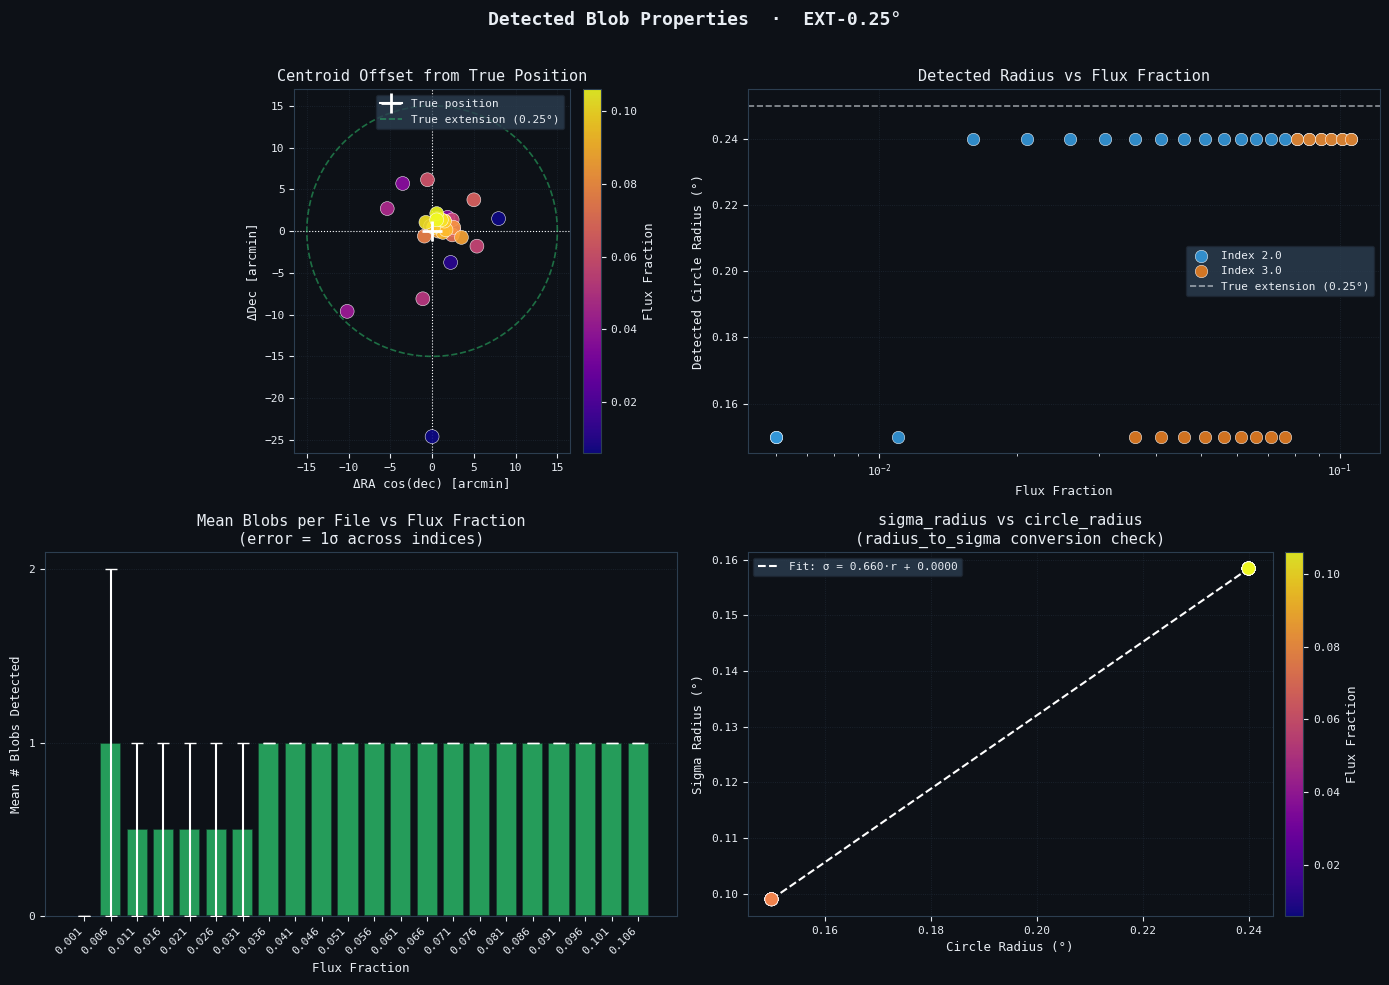

Fig 2 saved


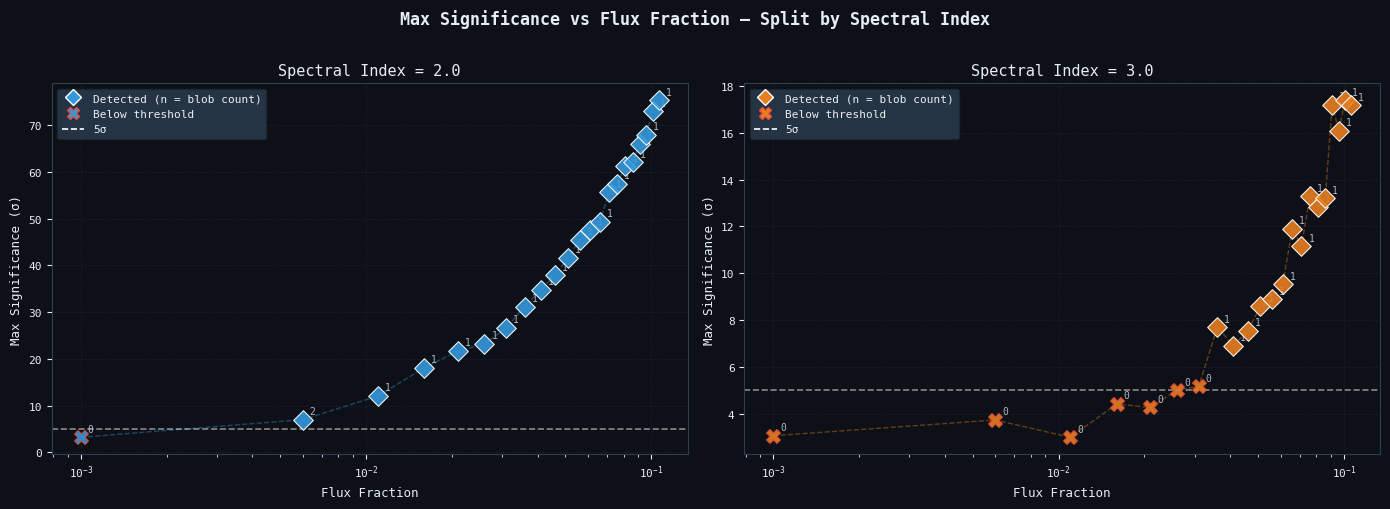

Fig 3 saved


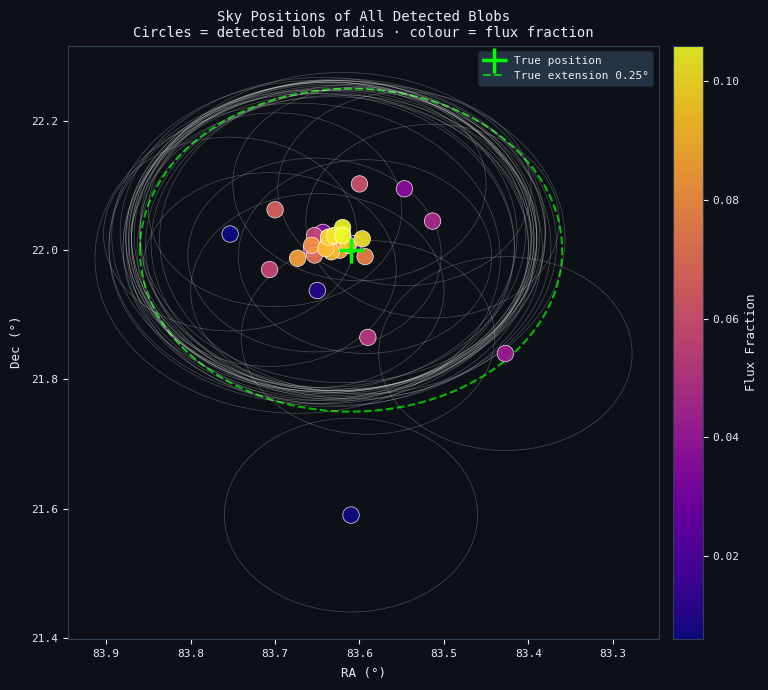

Fig 4 saved


In [18]:

# ══════════════════════════════════════════════════════════════════════════════
# Figure 1 — Overview & detection rate
# ══════════════════════════════════════════════════════════════════════════════
fig1, axes1 = plt.subplots(2, 2, figsize=(14, 10))
fig1.suptitle('Blob Detection Diagnostics  ·  EXT-0.25°  ·  All indices',
              fontsize=13, fontweight='bold', color=FG, y=0.98)
fig1.patch.set_facecolor(BG)

# ── 1a: Max significance vs flux fraction, coloured by status & index ─────────
ax = axes1[0, 0]
for r in records:
    col  = C_DET if r['status'] == 'detected' else C_BEL
    mark = 'o' if r['spectral_index'] == 2.0 else 's'
    ax.scatter(r['flux_fraction'], r['max_significance'],
               color=col, marker=mark, s=90, zorder=3,
               edgecolors='white', linewidths=0.4, alpha=0.9)

ax.axhline(5.0, color='white', lw=1.2, ls='--', alpha=0.6,
           label='5σ threshold')
ax.set_xlabel('Flux Fraction')
ax.set_ylabel('Max Significance (σ)')
ax.set_title('Max Significance vs Flux Fraction')
ax.grid(True, ls=':')
ax.set_xscale('log')

legend_els = [
    mpatches.Patch(color=C_DET, label='Detected'),
    mpatches.Patch(color=C_BEL, label='Below threshold'),
    Line2D([0], [0], marker='o', color='none', markerfacecolor=FG,
           markersize=7, label='Index 2.0'),
    Line2D([0], [0], marker='s', color='none', markerfacecolor=FG,
           markersize=7, label='Index 3.0'),
    Line2D([0], [0], color='white', ls='--', lw=1.2, label='5σ threshold'),
]
ax.legend(handles=legend_els, loc='upper left')

# ── 1b: Detection fraction vs flux fraction per spectral index ─────────────────
ax = axes1[0, 1]
for idx_val, col, lbl in [(2.0, C_IDX2, 'Index 2.0'),
                           (3.0, C_IDX3, 'Index 3.0')]:
    ffs  = sorted(set(r['flux_fraction'] for r in records
                      if r['spectral_index'] == idx_val))
    fracs = []
    for ff in ffs:
        subset = [r for r in records
                  if r['spectral_index'] == idx_val
                  and r['flux_fraction'] == ff]
        n_det = sum(1 for r in subset if r['status'] == 'detected')
        fracs.append(n_det / len(subset) if subset else 0)
    ax.plot(ffs, fracs, color=col, marker='o', lw=2, ms=7,
            label=lbl, zorder=3)
    ax.fill_between(ffs, fracs, alpha=0.12, color=col)

ax.set_xlabel('Flux Fraction')
ax.set_ylabel('Detection Fraction')
ax.set_title('Detection Rate vs Flux Fraction')
ax.set_ylim(-0.05, 1.15)
ax.set_xscale('log')
ax.axhline(1.0, color=FG, lw=0.7, ls=':', alpha=0.4)
ax.axhline(0.5, color=FG, lw=0.7, ls=':', alpha=0.4)
ax.grid(True, ls=':')
ax.legend()

# ── 1c: Status breakdown bar chart ────────────────────────────────────────────
ax = axes1[1, 0]
labels  = ['Detected', 'Below 5σ', 'No Blobs']
counts  = [len(det), len(below), len(nob)]
colors  = [C_DET, C_BEL, C_NOB]
bars = ax.bar(labels, counts, color=colors, width=0.5,
              edgecolor=BG, linewidth=1.5, zorder=3)
for bar, cnt in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.1,
            str(cnt), ha='center', va='bottom',
            color=FG, fontsize=10, fontweight='bold')
ax.set_ylabel('Number of Files')
ax.set_title(f'Status Breakdown  (N={len(records)} files)')
ax.set_ylim(0, max(counts) * 1.3)
ax.yaxis.set_major_locator(MaxNLocator(integer=True))
ax.grid(True, axis='y', ls=':')

# ── 1d: Max significance distribution split by status ─────────────────────────
ax = axes1[1, 1]
bins = np.linspace(2.5, 25, 18)
if below:
    ax.hist([r['max_significance'] for r in below],
            bins=bins, color=C_BEL, alpha=0.75,
            label='Below threshold', edgecolor=BG, lw=0.8)
if det:
    ax.hist([r['max_significance'] for r in det],
            bins=bins, color=C_DET, alpha=0.75,
            label='Detected', edgecolor=BG, lw=0.8)
ax.axvline(5.0, color='white', lw=1.4, ls='--', label='5σ', zorder=5)
ax.set_xlabel('Max Significance (σ)')
ax.set_ylabel('Count')
ax.set_title('Significance Distribution by Status')
ax.legend()
ax.grid(True, ls=':')

fig1.tight_layout(rect=[0, 0, 1, 0.97])
# fig1.savefig('/home/claude/diag_fig1_overview.png',
#              dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
plt.close(fig1)
print("Fig 1 saved")

# ══════════════════════════════════════════════════════════════════════════════
# Figure 2 — Detected-blob properties
# ══════════════════════════════════════════════════════════════════════════════
fig2, axes2 = plt.subplots(2, 2, figsize=(14, 10))
fig2.suptitle('Detected Blob Properties  ·  EXT-0.25°',
              fontsize=13, fontweight='bold', color=FG, y=0.98)
fig2.patch.set_facecolor(BG)

# ── 2a: RA offset from true position ─────────────────────────────────────────
ax = axes2[0, 0]
if blobs:
    ra_off  = [(b['ra']  - true_ra)  * np.cos(np.radians(true_dec)) * 60
               for b in blobs]
    dec_off = [(b['dec'] - true_dec) * 60 for b in blobs]
    ffs     = [b['flux_fraction'] for b in blobs]
    sc = ax.scatter(ra_off, dec_off,
                    c=ffs, cmap='plasma',
                    s=100, edgecolors='white', linewidths=0.4,
                    zorder=3, alpha=0.9)
    cb = fig2.colorbar(sc, ax=ax, pad=0.02)
    cb.set_label('Flux Fraction', color=FG)
    cb.ax.yaxis.set_tick_params(color=FG)
    plt.setp(cb.ax.yaxis.get_ticklabels(), color=FG)

ax.axhline(0, color='white', lw=0.8, ls=':')
ax.axvline(0, color='white', lw=0.8, ls=':')
ax.plot(0, 0, marker='+', color='white', ms=14, mew=2, zorder=5,
        label='True position')
theta = np.linspace(0, 2*np.pi, 200)
ax.plot(0.25*60*np.cos(theta), 0.25*60*np.sin(theta),
        color=C_DET, lw=1.2, ls='--', alpha=0.5,
        label='True extension (0.25°)')
ax.set_xlabel('ΔRA cos(dec) [arcmin]')
ax.set_ylabel('ΔDec [arcmin]')
ax.set_title('Centroid Offset from True Position')
ax.set_aspect('equal')
ax.legend(loc='upper right')
ax.grid(True, ls=':')

# ── 2b: Detected circle radius vs flux fraction ────────────────────────────────
ax = axes2[0, 1]
if blobs:
    for idx_val, col, lbl in [(2.0, C_IDX2, 'Index 2.0'),
                               (3.0, C_IDX3, 'Index 3.0')]:
        sub = [b for b in blobs if b['spectral_index'] == idx_val]
        if sub:
            ax.scatter([b['flux_fraction'] for b in sub],
                       [b['circle_radius'] for b in sub],
                       color=col, s=80,
                       edgecolors='white', linewidths=0.4,
                       label=lbl, zorder=3, alpha=0.9)

ax.axhline(0.25, color=FG, lw=1.2, ls='--', alpha=0.6,
           label='True extension (0.25°)')
ax.set_xlabel('Flux Fraction')
ax.set_ylabel('Detected Circle Radius (°)')
ax.set_title('Detected Radius vs Flux Fraction')
ax.set_xscale('log')
ax.legend()
ax.grid(True, ls=':')

# ── 2c: Number of blobs detected per file ─────────────────────────────────────
ax = axes2[1, 0]
ff_ndets = defaultdict(list)
for r in records:
    ff_ndets[r['flux_fraction']].append(r['n_detected'])

ffs_sorted = sorted(ff_ndets)
means = [np.mean(ff_ndets[ff]) for ff in ffs_sorted]
stds  = [np.std(ff_ndets[ff])  for ff in ffs_sorted]
xpos  = np.arange(len(ffs_sorted))

ax.bar(xpos, means, color=C_DET, alpha=0.75,
       edgecolor=BG, linewidth=1.2, zorder=3)
ax.errorbar(xpos, means, yerr=stds,
            fmt='none', color='white', capsize=4, lw=1.5, zorder=4)
ax.set_xticks(xpos)
ax.set_xticklabels([f'{ff:.3f}' for ff in ffs_sorted], rotation=45, ha='right')
ax.set_xlabel('Flux Fraction')
ax.set_ylabel('Mean # Blobs Detected')
ax.set_title('Mean Blobs per File vs Flux Fraction\n(error = 1σ across indices)')
ax.yaxis.set_major_locator(MaxNLocator(integer=True))
ax.grid(True, axis='y', ls=':')

# ── 2d: sigma_radius vs circle_radius  (should be ~linear) ────────────────────
ax = axes2[1, 1]
if blobs:
    cr = [b['circle_radius'] for b in blobs]
    sr = [b['sigma_radius']  for b in blobs]
    ff = [b['flux_fraction'] for b in blobs]
    sc = ax.scatter(cr, sr, c=ff, cmap='plasma',
                    s=90, edgecolors='white', linewidths=0.4,
                    zorder=3, alpha=0.9)
    cb = fig2.colorbar(sc, ax=ax, pad=0.02)
    cb.set_label('Flux Fraction', color=FG)
    cb.ax.yaxis.set_tick_params(color=FG)
    plt.setp(cb.ax.yaxis.get_ticklabels(), color=FG)
    # Fit line
    if len(cr) > 1:
        m, b_coef = np.polyfit(cr, sr, 1)
        xs = np.linspace(min(cr), max(cr), 100)
        ax.plot(xs, m*xs + b_coef, color='white', lw=1.5, ls='--',
                label=f'Fit: σ = {m:.3f}·r + {b_coef:.4f}')
        ax.legend()

ax.set_xlabel('Circle Radius (°)')
ax.set_ylabel('Sigma Radius (°)')
ax.set_title('sigma_radius vs circle_radius\n(radius_to_sigma conversion check)')
ax.grid(True, ls=':')

fig2.tight_layout(rect=[0, 0, 1, 0.97])
# fig2.savefig('/home/claude/diag_fig2_blobs.png',
#              dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
plt.close(fig2)
print("Fig 2 saved")

# ══════════════════════════════════════════════════════════════════════════════
# Figure 3 — Per-spectral-index deep-dive
# ══════════════════════════════════════════════════════════════════════════════
fig3, axes3 = plt.subplots(1, 2, figsize=(14, 5))
fig3.suptitle('Max Significance vs Flux Fraction — Split by Spectral Index',
              fontsize=12, fontweight='bold', color=FG, y=1.01)
fig3.patch.set_facecolor(BG)

for ax, idx_val, col, lbl in [
        (axes3[0], 2.0, C_IDX2, 'Spectral Index = 2.0'),
        (axes3[1], 3.0, C_IDX3, 'Spectral Index = 3.0')]:

    sub = [r for r in records if r['spectral_index'] == idx_val]
    for r in sub:
        mk   = 'D' if r['status'] == 'detected' else 'X'
        ecol = 'white' if r['status'] == 'detected' else C_BEL
        ax.scatter(r['flux_fraction'], r['max_significance'],
                   color=col, marker=mk, s=100, zorder=3,
                   edgecolors=ecol, linewidths=0.8, alpha=0.9)
        ax.annotate(f"{r['n_detected']}",
                    (r['flux_fraction'], r['max_significance']),
                    textcoords='offset points', xytext=(5, 4),
                    fontsize=7, color=FG, alpha=0.75)

    # connect points with a line for visual trend
    sub_s = sorted(sub, key=lambda x: x['flux_fraction'])
    ax.plot([r['flux_fraction'] for r in sub_s],
            [r['max_significance'] for r in sub_s],
            color=col, lw=1.0, ls='--', alpha=0.4, zorder=2)

    ax.axhline(5.0, color='white', lw=1.2, ls='--',
               alpha=0.5, label='5σ')
    ax.set_xlabel('Flux Fraction')
    ax.set_ylabel('Max Significance (σ)')
    ax.set_title(lbl)
    ax.set_xscale('log')
    ax.grid(True, ls=':')

    legend_els = [
        Line2D([0],[0], marker='D', color='none',
               markerfacecolor=col, markeredgecolor='white',
               markersize=8, label='Detected (n = blob count)'),
        Line2D([0],[0], marker='X', color='none',
               markerfacecolor=col, markeredgecolor=C_BEL,
               markersize=8, label='Below threshold'),
        Line2D([0],[0], color='white', ls='--', lw=1.2, label='5σ'),
    ]
    ax.legend(handles=legend_els)

fig3.tight_layout()
# fig3.savefig('/home/claude/diag_fig3_byindex.png',
#              dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
plt.close(fig3)
print("Fig 3 saved")

# ══════════════════════════════════════════════════════════════════════════════
# Figure 4 — RA / Dec scatter of all detected blobs
# ══════════════════════════════════════════════════════════════════════════════
fig4, ax4 = plt.subplots(figsize=(8, 7))
fig4.patch.set_facecolor(BG)
ax4.set_facecolor(BG)

if blobs:
    ffs_all = [b['flux_fraction'] for b in blobs]
    sc = ax4.scatter([b['ra']  for b in blobs],
                     [b['dec'] for b in blobs],
                     c=ffs_all, cmap='plasma',
                     s=140, edgecolors='white', linewidths=0.5,
                     zorder=4, alpha=0.9)
    # Draw circle for each blob
    for b in blobs:
        circle = plt.Circle((b['ra'], b['dec']),
                             b['circle_radius'],
                             fill=False, edgecolor='white',
                             lw=0.5, alpha=0.25, zorder=3)
        ax4.add_patch(circle)
    cb = fig4.colorbar(sc, ax=ax4, pad=0.02)
    cb.set_label('Flux Fraction', color=FG)
    cb.ax.yaxis.set_tick_params(color=FG)
    plt.setp(cb.ax.yaxis.get_ticklabels(), color=FG)

# True position + true extension ring
ax4.plot(true_ra, true_dec, marker='+', color='lime',
         ms=18, mew=2.5, zorder=6, label='True position')
theta = np.linspace(0, 2*np.pi, 300)
ax4.plot(true_ra + 0.25*np.cos(theta),
         true_dec + 0.25*np.sin(theta),
         color='lime', lw=1.5, ls='--', alpha=0.7,
         label='True extension 0.25°')

ax4.set_xlabel('RA (°)', labelpad=6)
ax4.set_ylabel('Dec (°)', labelpad=6)
ax4.set_title('Sky Positions of All Detected Blobs\n'
              'Circles = detected blob radius · colour = flux fraction',
              fontsize=10)
ax4.invert_xaxis()   # RA increases to the left
ax4.legend(loc='upper right')
ax4.grid(True, ls=':', alpha=0.5)

fig4.tight_layout()
fig4.savefig('/home/claude/diag_fig4_skypos.png',
             dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
plt.close(fig4)
print("Fig 4 saved")
plt.show()
# ══════════════════════════════════════════════════════════════════════════════
# Merge all into one PDF
# ══════════════════════════════════════════════════════════════════════════════
# from matplotlib.backends.backend_pdf import PdfPages
# import matplotlib.image as mpimg

# pdf_path = 'blob_detection_diagnostics.pdf'
# with PdfPages(pdf_path) as pdf:
#     page_titles = [
#         ('diag_fig1_overview.png',
#          'Fig 1 · Overview: significance, detection rate, status breakdown'),
#         ('diag_fig2_blobs.png',
#          'Fig 2 · Detected blob properties: offsets, radii, counts'),
#         ('diag_fig3_byindex.png',
#          'Fig 3 · Per spectral-index deep-dive'),
#         ('diag_fig4_skypos.png',
#          'Fig 4 · Sky positions of all detected blobs'),
#     ]
#     for imgfile, title in page_titles:
#         img = mpimg.imread(f'/home/claude/{imgfile}')
#         fig, ax = plt.subplots(figsize=(14, 10))
#         fig.patch.set_facecolor(BG)
#         ax.imshow(img)
#         ax.axis('off')
#         fig.text(0.5, 0.01, title, ha='center', fontsize=8,
#                  color='#888', fontfamily='monospace')
#         pdf.savefig(fig, facecolor=BG, bbox_inches='tight')
#         plt.close(fig)

# print(f"\nPDF saved → {pdf_path}")

Total records : 44
  Detected    : 37
  Below 5σ    : 7
  No blobs    : 0
  Total blobs : 38  (PS: 27  EXT: 11)


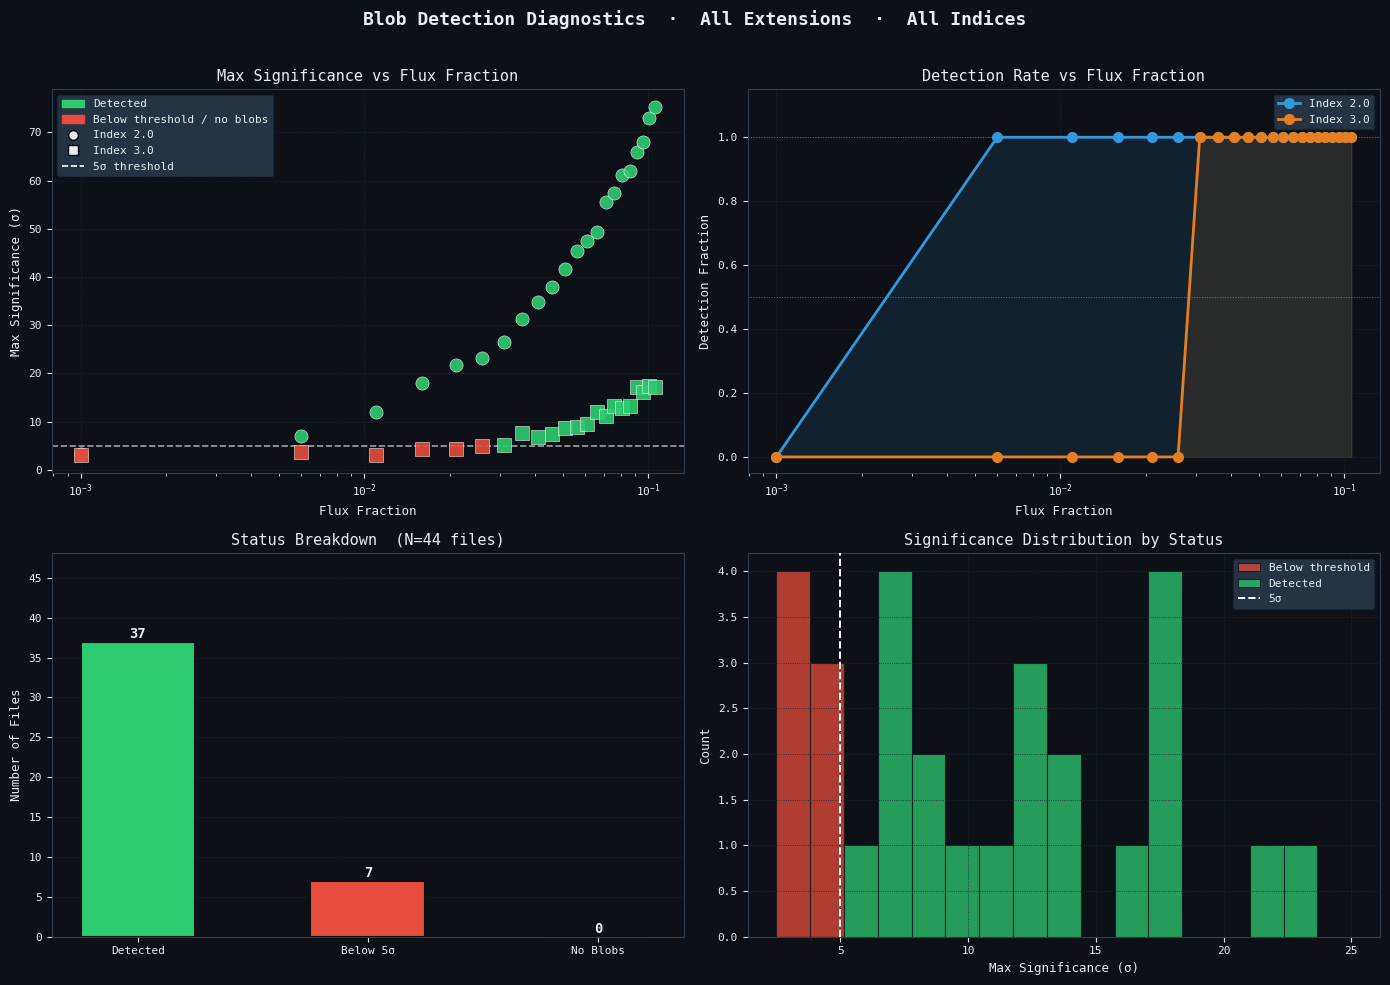

Fig 1 done


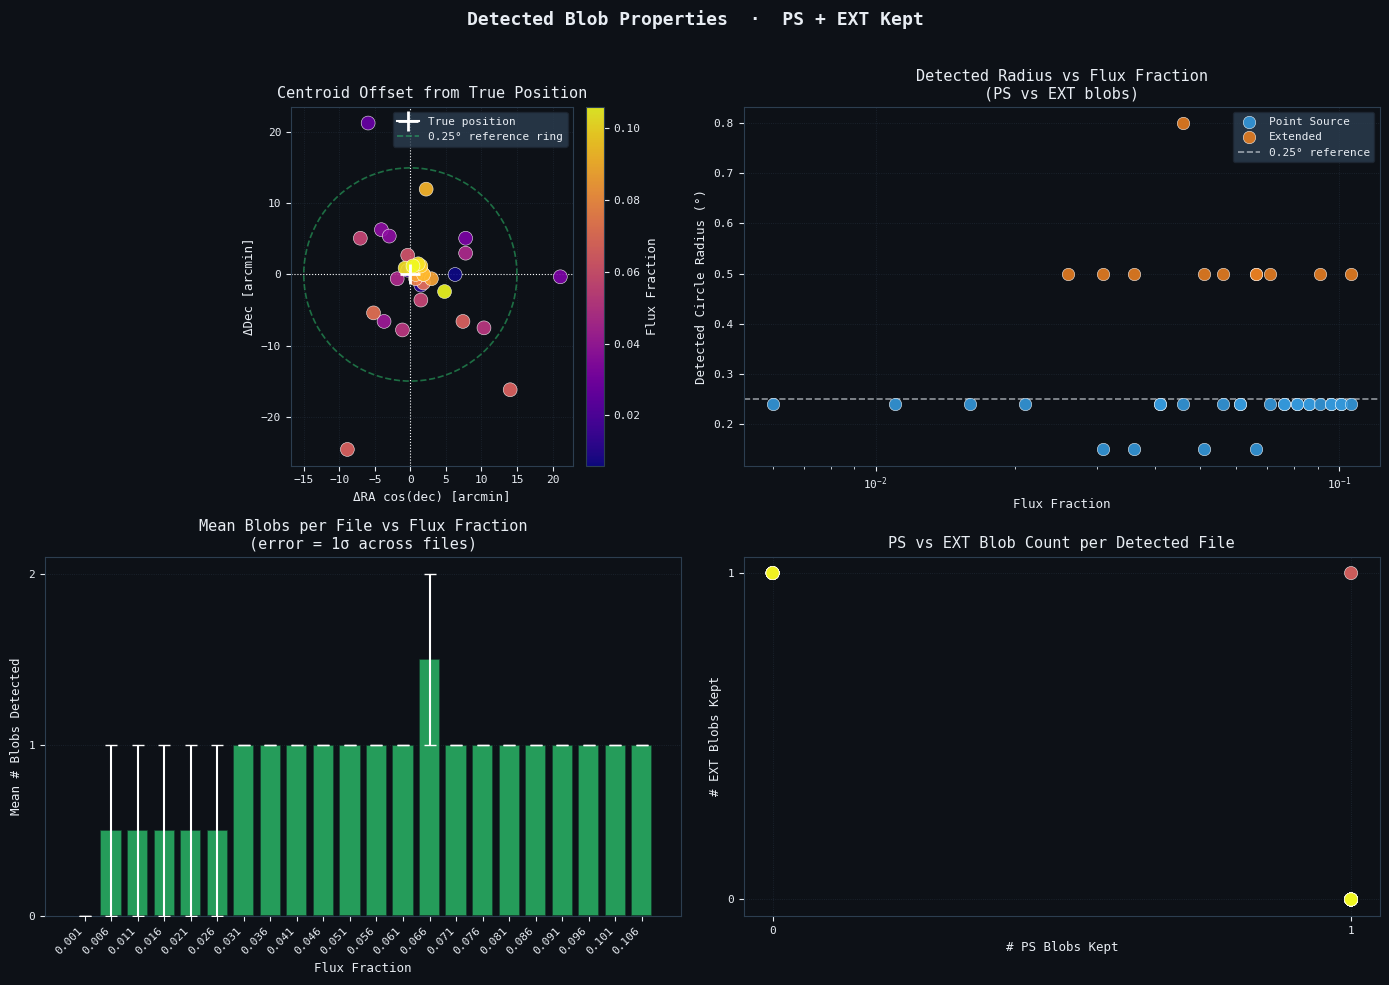

Fig 2 done


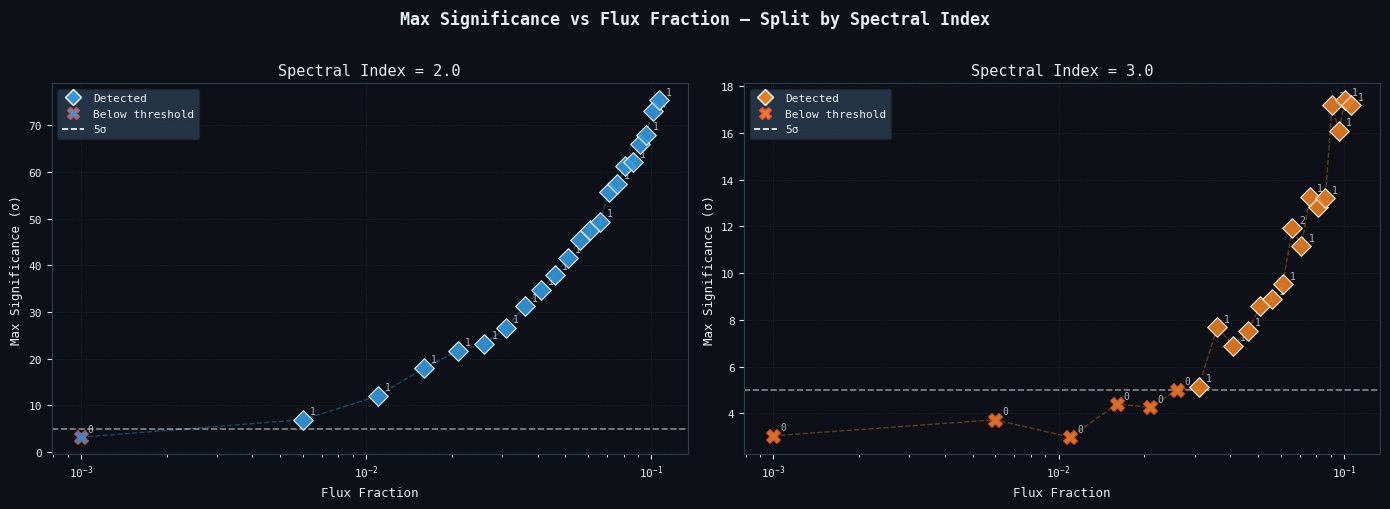

Fig 3 done


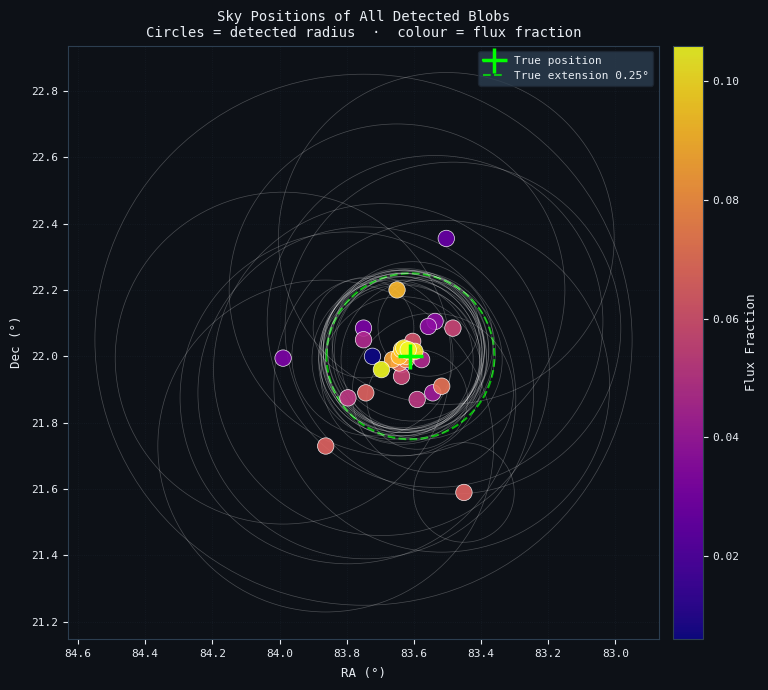

Fig 4 done

  Match radius : 0.2°
  True source  : RA=83.61°  Dec=22.0°
  TP files     :   32   (detected + matched)
  FP files     :    5   (detected + not matched)
  FN files     :    0   (≥5σ map  + no detection)
  TN files     :    7   (below threshold)
──────────────────────────────────────────────────
  TP blobs     :   32
  FP blobs     :    6
──────────────────────────────────────────────────
  Precision    : 0.865
  Recall       : 1.000
  F1 score     : 0.928



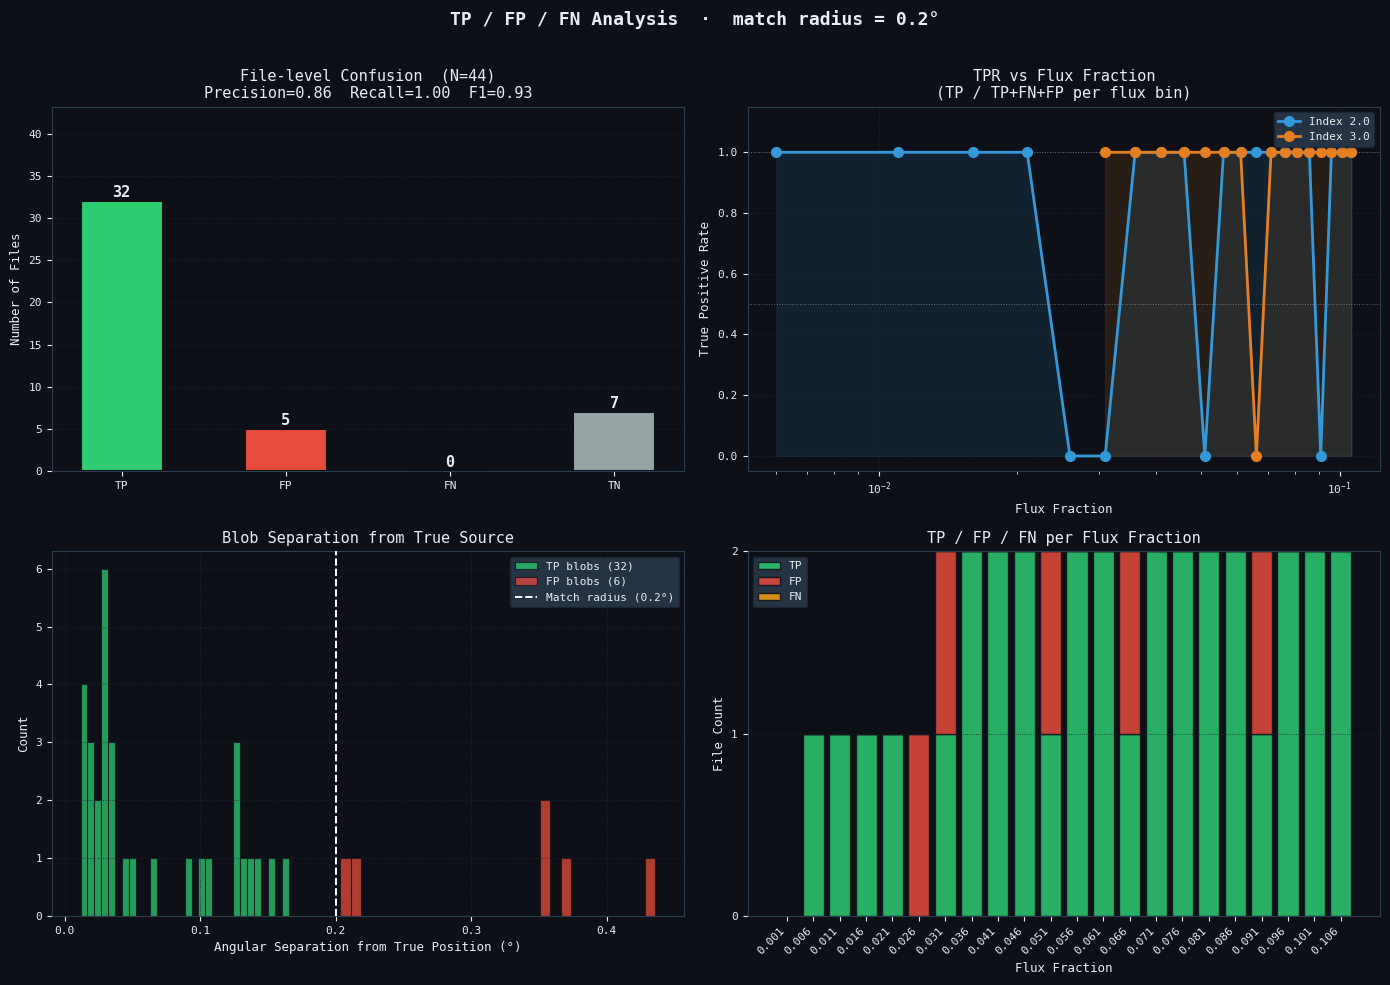

Fig 5 done


In [1]:
import yaml
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from matplotlib.ticker import MaxNLocator
from collections import defaultdict
%matplotlib inline
# ── Palette ───────────────────────────────────────────────────────────────────
C_DET  = '#2ECC71'
C_BEL  = '#E74C3C'
C_NOB  = '#F39C12'
C_IDX2 = '#3498DB'
C_IDX3 = '#E67E22'
BG     = '#0D1117'
FG     = '#E8EDF3'
GRID   = '#1E2733'
SPINE  = '#2C3E50'

plt.rcParams.update({
    'figure.facecolor': BG,  'axes.facecolor':   BG,
    'axes.edgecolor':  SPINE, 'axes.labelcolor':  FG,
    'axes.titlecolor': FG,    'text.color':       FG,
    'xtick.color':     FG,    'ytick.color':      FG,
    'grid.color':      GRID,  'grid.linewidth':   0.6,
    'font.family':     'monospace',
    'axes.titlesize':  11,    'axes.labelsize':   9,
    'xtick.labelsize': 8,     'ytick.labelsize':  8,
    'legend.fontsize': 8,     'legend.facecolor': SPINE,
    'legend.edgecolor': GRID,
})

# ══════════════════════════════════════════════════════════════════════════════
# Load kept YAML
# ══════════════════════════════════════════════════════════════════════════════
YAML_PATH = '/lustre/hawcz01/scratch/userspace/rbabu/astroimage/AstroImageDetection/new_results/blob_detection_kept.yaml'

with open(YAML_PATH) as f:
    raw = yaml.safe_load(f)

# ── Flatten into records ──────────────────────────────────────────────────────
records = []
for fname, v in raw.items():
    ps_kept  = v.get('ps_kept')  or []
    ext_kept = v.get('ext_kept') or []
    n_det    = len(ps_kept) + len(ext_kept)
    if v.get('true_extension') == 0.25:
        r = {
            'filename':       fname,
            'source_type':    v.get('source_type'),
            'true_extension': v.get('true_extension'),
            'flux_fraction':  v.get('flux_fraction'),
            'spectral_index': v.get('spectral_index'),
            'status':         v.get('status'),
            'max_significance': v.get('max_significance'),
            'n_detected':     n_det,
            'ps_kept':        ps_kept,
            'ext_kept':       ext_kept,
        }
        records.append(r)

# ── Convenience subsets ───────────────────────────────────────────────────────
det   = [r for r in records if r['status'] == 'detected']
below = [r for r in records if r['status'] == 'below_threshold']
nob   = [r for r in records if r['status'] == 'no_blobs']
idx2  = [r for r in records if r['spectral_index'] == 2.0]
idx3  = [r for r in records if r['spectral_index'] == 3.0]
all_ff = sorted(set(r['flux_fraction'] for r in records if r['flux_fraction'] is not None))

# ── Flat blob list — one entry per detected blob (PS + EXT combined) ──────────
blobs = []
for r in det:
    for b in (r['ps_kept'] + r['ext_kept']):
        blobs.append({
            **b,
            'flux_fraction':  r['flux_fraction'],
            'true_extension': r['true_extension'],
            'spectral_index': r['spectral_index'],
            # normalise field names: kept YAML uses l_deg/b_deg, convert to ra/dec
            'ra':             b.get('ra',  b.get('l_deg')),
            'dec':            b.get('dec', b.get('b_deg')),
            'circle_radius':  b.get('circle_radius',  b.get('radius_deg')),
            'sigma_radius':   b.get('sigma_radius',   b.get('radius_deg')),
        })

true_ra  = 83.61
true_dec = 22.0
# true_ra, true_dec =225.63, 72.25
print(f"Total records : {len(records)}")
print(f"  Detected    : {len(det)}")
print(f"  Below 5σ    : {len(below)}")
print(f"  No blobs    : {len(nob)}")
print(f"  Total blobs : {len(blobs)}  "
      f"(PS: {sum(len(r['ps_kept']) for r in det)}  "
      f"EXT: {sum(len(r['ext_kept']) for r in det)})")


# ══════════════════════════════════════════════════════════════════════════════
# Figure 1 — Overview & detection rate
# ══════════════════════════════════════════════════════════════════════════════
fig1, axes1 = plt.subplots(2, 2, figsize=(14, 10))
fig1.suptitle('Blob Detection Diagnostics  ·  All Extensions  ·  All Indices',
              fontsize=13, fontweight='bold', color=FG, y=0.98)
fig1.patch.set_facecolor(BG)

# ── 1a: Max significance vs flux fraction ─────────────────────────────────────
ax = axes1[0, 0]
for r in records:
    if r['flux_fraction'] is None or r['max_significance'] is None:
        continue
    col  = C_DET if r['status'] == 'detected' else C_BEL
    mark = 'o' if r['spectral_index'] == 2.0 else 's'
    ax.scatter(r['flux_fraction'], r['max_significance'],
               color=col, marker=mark, s=90, zorder=3,
               edgecolors='white', linewidths=0.4, alpha=0.9)

ax.axhline(5.0, color='white', lw=1.2, ls='--', alpha=0.6, label='5σ threshold')
ax.set_xlabel('Flux Fraction')
ax.set_ylabel('Max Significance (σ)')
ax.set_title('Max Significance vs Flux Fraction')
ax.set_xscale('log')
ax.grid(True, ls=':')
ax.legend(handles=[
    mpatches.Patch(color=C_DET, label='Detected'),
    mpatches.Patch(color=C_BEL, label='Below threshold / no blobs'),
    Line2D([0],[0], marker='o', color='none', markerfacecolor=FG, markersize=7, label='Index 2.0'),
    Line2D([0],[0], marker='s', color='none', markerfacecolor=FG, markersize=7, label='Index 3.0'),
    Line2D([0],[0], color='white', ls='--', lw=1.2, label='5σ threshold'),
], loc='upper left')

# ── 1b: Detection fraction vs flux fraction per spectral index ────────────────
ax = axes1[0, 1]
for idx_val, col, lbl in [(2.0, C_IDX2, 'Index 2.0'), (3.0, C_IDX3, 'Index 3.0')]:
    ffs   = sorted(set(r['flux_fraction'] for r in records
                       if r['spectral_index'] == idx_val and r['flux_fraction'] is not None))
    fracs = []
    for ff in ffs:
        subset = [r for r in records if r['spectral_index'] == idx_val and r['flux_fraction'] == ff]
        fracs.append(sum(1 for r in subset if r['status'] == 'detected') / len(subset) if subset else 0)
    ax.plot(ffs, fracs, color=col, marker='o', lw=2, ms=7, label=lbl, zorder=3)
    ax.fill_between(ffs, fracs, alpha=0.12, color=col)

ax.axhline(1.0, color=FG, lw=0.7, ls=':', alpha=0.4)
ax.axhline(0.5, color=FG, lw=0.7, ls=':', alpha=0.4)
ax.set_xlabel('Flux Fraction');  ax.set_ylabel('Detection Fraction')
ax.set_title('Detection Rate vs Flux Fraction')
ax.set_ylim(-0.05, 1.15);  ax.set_xscale('log')
ax.grid(True, ls=':');  ax.legend()

# ── 1c: Status breakdown bar chart ────────────────────────────────────────────
ax = axes1[1, 0]
labels = ['Detected', 'Below 5σ', 'No Blobs']
counts = [len(det), len(below), len(nob)]
bars   = ax.bar(labels, counts, color=[C_DET, C_BEL, C_NOB],
                width=0.5, edgecolor=BG, linewidth=1.5, zorder=3)
for bar, cnt in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            str(cnt), ha='center', va='bottom', color=FG, fontsize=10, fontweight='bold')
ax.set_ylabel('Number of Files')
ax.set_title(f'Status Breakdown  (N={len(records)} files)')
ax.set_ylim(0, max(counts) * 1.3 if counts else 1)
ax.yaxis.set_major_locator(MaxNLocator(integer=True))
ax.grid(True, axis='y', ls=':')

# ── 1d: Max significance distribution by status ───────────────────────────────
ax = axes1[1, 1]
bins = np.linspace(2.5, 25, 18)
if below:
    ax.hist([r['max_significance'] for r in below if r['max_significance']],
            bins=bins, color=C_BEL, alpha=0.75, label='Below threshold', edgecolor=BG, lw=0.8)
if det:
    ax.hist([r['max_significance'] for r in det if r['max_significance']],
            bins=bins, color=C_DET, alpha=0.75, label='Detected', edgecolor=BG, lw=0.8)
ax.axvline(5.0, color='white', lw=1.4, ls='--', label='5σ', zorder=5)
ax.set_xlabel('Max Significance (σ)');  ax.set_ylabel('Count')
ax.set_title('Significance Distribution by Status')
ax.legend();  ax.grid(True, ls=':')

fig1.tight_layout(rect=[0, 0, 1, 0.97])
plt.show();  plt.close(fig1)
print("Fig 1 done")


# ══════════════════════════════════════════════════════════════════════════════
# Figure 2 — Detected blob properties
# ══════════════════════════════════════════════════════════════════════════════
fig2, axes2 = plt.subplots(2, 2, figsize=(14, 10))
fig2.suptitle('Detected Blob Properties  ·  PS + EXT Kept',
              fontsize=13, fontweight='bold', color=FG, y=0.98)
fig2.patch.set_facecolor(BG)

# ── 2a: Centroid offset from true position ────────────────────────────────────
ax = axes2[0, 0]
if blobs:
    ra_off  = [(b['ra']  - true_ra)  * np.cos(np.radians(true_dec)) * 60 for b in blobs]
    dec_off = [(b['dec'] - true_dec) * 60 for b in blobs]
    sc = ax.scatter(ra_off, dec_off,
                    c=[b['flux_fraction'] for b in blobs], cmap='plasma',
                    s=100, edgecolors='white', linewidths=0.4, zorder=3, alpha=0.9)
    cb = fig2.colorbar(sc, ax=ax, pad=0.02)
    cb.set_label('Flux Fraction', color=FG)
    cb.ax.yaxis.set_tick_params(color=FG)
    plt.setp(cb.ax.yaxis.get_ticklabels(), color=FG)

ax.axhline(0, color='white', lw=0.8, ls=':')
ax.axvline(0, color='white', lw=0.8, ls=':')
ax.plot(0, 0, marker='+', color='white', ms=14, mew=2, zorder=5, label='True position')
theta = np.linspace(0, 2*np.pi, 200)
ax.plot(0.25*60*np.cos(theta), 0.25*60*np.sin(theta),
        color=C_DET, lw=1.2, ls='--', alpha=0.5, label='0.25° reference ring')
ax.set_xlabel('ΔRA cos(dec) [arcmin]');  ax.set_ylabel('ΔDec [arcmin]')
ax.set_title('Centroid Offset from True Position')
ax.set_aspect('equal');  ax.legend(loc='upper right');  ax.grid(True, ls=':')

# ── 2b: Detected radius vs flux fraction, split by blob type ─────────────────
ax = axes2[0, 1]
if blobs:
    for blob_label, col, lbl in [('PS', C_IDX2, 'Point Source'), ('EXT', C_IDX3, 'Extended')]:
        sub = [b for b in blobs if b.get('label') == blob_label]
        if sub:
            ax.scatter([b['flux_fraction'] for b in sub],
                       [b['circle_radius']  for b in sub],
                       color=col, s=80, edgecolors='white', linewidths=0.4,
                       label=lbl, zorder=3, alpha=0.9)

ax.axhline(0.25, color=FG, lw=1.2, ls='--', alpha=0.6, label='0.25° reference')
ax.set_xlabel('Flux Fraction');  ax.set_ylabel('Detected Circle Radius (°)')
ax.set_title('Detected Radius vs Flux Fraction\n(PS vs EXT blobs)')
ax.set_xscale('log');  ax.legend();  ax.grid(True, ls=':')

# ── 2c: Mean blobs per file vs flux fraction ──────────────────────────────────
ax = axes2[1, 0]
ff_ndets = defaultdict(list)
for r in records:
    if r['flux_fraction'] is not None:
        ff_ndets[r['flux_fraction']].append(r['n_detected'])

ffs_sorted = sorted(ff_ndets)
means = [np.mean(ff_ndets[ff]) for ff in ffs_sorted]
stds  = [np.std(ff_ndets[ff])  for ff in ffs_sorted]
xpos  = np.arange(len(ffs_sorted))

ax.bar(xpos, means, color=C_DET, alpha=0.75, edgecolor=BG, linewidth=1.2, zorder=3)
ax.errorbar(xpos, means, yerr=stds, fmt='none', color='white', capsize=4, lw=1.5, zorder=4)
ax.set_xticks(xpos)
ax.set_xticklabels([f'{ff:.3f}' for ff in ffs_sorted], rotation=45, ha='right')
ax.set_xlabel('Flux Fraction');  ax.set_ylabel('Mean # Blobs Detected')
ax.set_title('Mean Blobs per File vs Flux Fraction\n(error = 1σ across files)')
ax.yaxis.set_major_locator(MaxNLocator(integer=True))
ax.grid(True, axis='y', ls=':')

# ── 2d: PS vs EXT blob count per file ────────────────────────────────────────
ax = axes2[1, 1]
ps_counts  = [len(r['ps_kept'])  for r in det]
ext_counts = [len(r['ext_kept']) for r in det]
ax.scatter(ps_counts, ext_counts,
           c=[r['flux_fraction'] for r in det], cmap='plasma',
           s=90, edgecolors='white', linewidths=0.4, zorder=3, alpha=0.9)
ax.set_xlabel('# PS Blobs Kept');  ax.set_ylabel('# EXT Blobs Kept')
ax.set_title('PS vs EXT Blob Count per Detected File')
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
ax.yaxis.set_major_locator(MaxNLocator(integer=True))
ax.grid(True, ls=':')

fig2.tight_layout(rect=[0, 0, 1, 0.97])
plt.show();  plt.close(fig2)
print("Fig 2 done")


# ══════════════════════════════════════════════════════════════════════════════
# Figure 3 — Per spectral index deep-dive
# ══════════════════════════════════════════════════════════════════════════════
fig3, axes3 = plt.subplots(1, 2, figsize=(14, 5))
fig3.suptitle('Max Significance vs Flux Fraction — Split by Spectral Index',
              fontsize=12, fontweight='bold', color=FG, y=1.01)
fig3.patch.set_facecolor(BG)

for ax, idx_val, col, lbl in [
        (axes3[0], 2.0, C_IDX2, 'Spectral Index = 2.0'),
        (axes3[1], 3.0, C_IDX3, 'Spectral Index = 3.0')]:
    sub = [r for r in records if r['spectral_index'] == idx_val
           and r['flux_fraction'] is not None and r['max_significance'] is not None]
    for r in sub:
        mk   = 'D' if r['status'] == 'detected' else 'X'
        ecol = 'white' if r['status'] == 'detected' else C_BEL
        ax.scatter(r['flux_fraction'], r['max_significance'],
                   color=col, marker=mk, s=100, zorder=3,
                   edgecolors=ecol, linewidths=0.8, alpha=0.9)
        ax.annotate(f"{r['n_detected']}",
                    (r['flux_fraction'], r['max_significance']),
                    textcoords='offset points', xytext=(5, 4),
                    fontsize=7, color=FG, alpha=0.75)

    sub_s = sorted(sub, key=lambda x: x['flux_fraction'])
    ax.plot([r['flux_fraction'] for r in sub_s],
            [r['max_significance'] for r in sub_s],
            color=col, lw=1.0, ls='--', alpha=0.4, zorder=2)

    ax.axhline(5.0, color='white', lw=1.2, ls='--', alpha=0.5, label='5σ')
    ax.set_xlabel('Flux Fraction');  ax.set_ylabel('Max Significance (σ)')
    ax.set_title(lbl);  ax.set_xscale('log');  ax.grid(True, ls=':')
    ax.legend(handles=[
        Line2D([0],[0], marker='D', color='none', markerfacecolor=col,
               markeredgecolor='white', markersize=8, label='Detected'),
        Line2D([0],[0], marker='X', color='none', markerfacecolor=col,
               markeredgecolor=C_BEL,   markersize=8, label='Below threshold'),
        Line2D([0],[0], color='white', ls='--', lw=1.2, label='5σ'),
    ])

fig3.tight_layout()
plt.show();  plt.close(fig3)
print("Fig 3 done")


# ══════════════════════════════════════════════════════════════════════════════
# Figure 4 — Sky positions of all detected blobs
# ══════════════════════════════════════════════════════════════════════════════
fig4, ax4 = plt.subplots(figsize=(8, 7))
fig4.patch.set_facecolor(BG);  ax4.set_facecolor(BG)

if blobs:
    sc = ax4.scatter([b['ra']  for b in blobs],
                     [b['dec'] for b in blobs],
                     c=[b['flux_fraction'] for b in blobs], cmap='plasma',
                     s=140, edgecolors='white', linewidths=0.5, zorder=4, alpha=0.9)
    for b in blobs:
        ax4.add_patch(plt.Circle((b['ra'], b['dec']), b['circle_radius'],
                                 fill=False, edgecolor='white', lw=0.5, alpha=0.25, zorder=3))
    cb = fig4.colorbar(sc, ax=ax4, pad=0.02)
    cb.set_label('Flux Fraction', color=FG)
    cb.ax.yaxis.set_tick_params(color=FG)
    plt.setp(cb.ax.yaxis.get_ticklabels(), color=FG)

theta = np.linspace(0, 2*np.pi, 300)
ax4.plot(true_ra, true_dec, marker='+', color='lime', ms=18, mew=2.5, zorder=6, label='True position')
ax4.plot(true_ra + 0.25*np.cos(theta), true_dec + 0.25*np.sin(theta),
         color='lime', lw=1.5, ls='--', alpha=0.7, label='True extension 0.25°')

ax4.set_xlabel('RA (°)', labelpad=6);  ax4.set_ylabel('Dec (°)', labelpad=6)
ax4.set_title('Sky Positions of All Detected Blobs\n'
              'Circles = detected radius  ·  colour = flux fraction', fontsize=10)
ax4.invert_xaxis();  ax4.legend(loc='upper right');  ax4.grid(True, ls=':', alpha=0.5)

fig4.tight_layout()
plt.show();  plt.close(fig4)
print("Fig 4 done")

# ══════════════════════════════════════════════════════════════════════════════
# True-positive / false-positive / false-negative classification
# ══════════════════════════════════════════════════════════════════════════════
MATCH_RADIUS_DEG = 0.2   # angular match tolerance

def angular_sep(ra1, dec1, ra2, dec2):
    """Great-circle separation in degrees."""
    ra1, dec1, ra2, dec2 = map(np.radians, [ra1, dec1, ra2, dec2])
    return np.degrees(np.arccos(np.clip(
        np.sin(dec1)*np.sin(dec2) + np.cos(dec1)*np.cos(dec2)*np.cos(ra1 - ra2),
        -1, 1
    )))

def classify_detections(records, true_ra, true_dec, match_radius=MATCH_RADIUS_DEG):
    """
    For each file classify its detected blobs as TP or FP, and the file
    itself as TP / FP / FN / TN.

    A blob is a True Positive  if its (ra, dec) is within match_radius of
    the true source position.
    A blob is a False Positive if it is detected but outside match_radius.

    File-level outcome
    ------------------
    TP  : file has ≥1 detected blob within match_radius
    FP  : file has detections but none within match_radius
    FN  : file has max_significance ≥ 5σ but zero blobs detected
    TN  : file is genuinely below threshold (max_sig < 5σ)
    """
    tp_files, fp_files, fn_files, tn_files = [], [], [], []
    tp_blobs, fp_blobs = [], []

    for r in records:
        all_blobs_in_file = r['ps_kept'] + r['ext_kept']

        # Annotate each blob with its match status
        matched_in_file = []
        for b in all_blobs_in_file:
            ra  = b.get('ra',  b.get('l_deg'))
            dec = b.get('dec', b.get('b_deg'))
            if ra is None or dec is None:
                continue
            sep = angular_sep(ra, dec, true_ra, true_dec)
            b_ann = {
                **b,
                'flux_fraction':  r['flux_fraction'],
                'true_extension': r['true_extension'],
                'spectral_index': r['spectral_index'],
                'sep_deg':        sep,
                'match':          sep <= match_radius,
            }
            if sep <= match_radius:
                tp_blobs.append(b_ann)
                matched_in_file.append(b_ann)
            else:
                fp_blobs.append(b_ann)

        # File-level verdict
        sig = r.get('max_significance') or 0
        if matched_in_file:
            tp_files.append(r)
        elif all_blobs_in_file:
            fp_files.append(r)           # blobs found, but none near true pos
        elif sig >= 5.0:
            fn_files.append(r)           # significant map but missed source
        else:
            tn_files.append(r)           # genuinely below threshold

    return tp_files, fp_files, fn_files, tn_files, tp_blobs, fp_blobs


tp_files, fp_files, fn_files, tn_files, tp_blobs, fp_blobs = classify_detections(
    records, true_ra, true_dec
)

# ── Summary stats ─────────────────────────────────────────────────────────────
n_tp = len(tp_files)
n_fp = len(fp_files)
n_fn = len(fn_files)
n_tn = len(tn_files)

precision = n_tp / (n_tp + n_fp) if (n_tp + n_fp) > 0 else float('nan')
recall    = n_tp / (n_tp + n_fn) if (n_tp + n_fn) > 0 else float('nan')
f1        = (2 * precision * recall / (precision + recall)
             if (precision + recall) > 0 else float('nan'))

print(f"\n{'='*50}")
print(f"  Match radius : {MATCH_RADIUS_DEG}°")
print(f"  True source  : RA={true_ra}°  Dec={true_dec}°")
print(f"{'='*50}")
print(f"  TP files     : {n_tp:>4}   (detected + matched)")
print(f"  FP files     : {n_fp:>4}   (detected + not matched)")
print(f"  FN files     : {n_fn:>4}   (≥5σ map  + no detection)")
print(f"  TN files     : {n_tn:>4}   (below threshold)")
print(f"{'─'*50}")
print(f"  TP blobs     : {len(tp_blobs):>4}")
print(f"  FP blobs     : {len(fp_blobs):>4}")
print(f"{'─'*50}")
print(f"  Precision    : {precision:.3f}")
print(f"  Recall       : {recall:.3f}")
print(f"  F1 score     : {f1:.3f}")
print(f"{'='*50}\n")


# ══════════════════════════════════════════════════════════════════════════════
# Figure 5 — TP / FP / FN breakdown
# ══════════════════════════════════════════════════════════════════════════════
C_TP = '#2ECC71'
C_FP = '#E74C3C'
C_FN = '#F39C12'
C_TN = '#95A5A6'

fig5, axes5 = plt.subplots(2, 2, figsize=(14, 10))
fig5.suptitle(f'TP / FP / FN Analysis  ·  match radius = {MATCH_RADIUS_DEG}°',
              fontsize=13, fontweight='bold', color=FG, y=0.98)
fig5.patch.set_facecolor(BG)

# ── 5a: Confusion bar chart ───────────────────────────────────────────────────
ax = axes5[0, 0]
labels  = ['TP', 'FP', 'FN', 'TN']
counts  = [n_tp, n_fp, n_fn, n_tn]
colors  = [C_TP, C_FP, C_FN, C_TN]
bars    = ax.bar(labels, counts, color=colors, width=0.5,
                 edgecolor=BG, linewidth=1.5, zorder=3)
for bar, cnt in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            str(cnt), ha='center', va='bottom',
            color=FG, fontsize=11, fontweight='bold')
ax.set_ylabel('Number of Files')
ax.set_title(f'File-level Confusion  (N={len(records)})\n'
             f'Precision={precision:.2f}  Recall={recall:.2f}  F1={f1:.2f}')
ax.set_ylim(0, max(counts) * 1.35 if counts else 1)
ax.yaxis.set_major_locator(MaxNLocator(integer=True))
ax.grid(True, axis='y', ls=':')

# ── 5b: Detection rate (TP / TP+FN) vs flux fraction ─────────────────────────
ax = axes5[0, 1]
for idx_val, col, lbl in [(2.0, C_IDX2, 'Index 2.0'), (3.0, C_IDX3, 'Index 3.0')]:
    ffs, tprs = [], []
    for ff in all_ff:
        tp_sub = [r for r in tp_files if r['flux_fraction'] == ff and r['spectral_index'] == idx_val]
        fn_sub = [r for r in fn_files if r['flux_fraction'] == ff and r['spectral_index'] == idx_val]
        fp_sub = [r for r in fp_files if r['flux_fraction'] == ff and r['spectral_index'] == idx_val]
        denom  = len(tp_sub) + len(fn_sub) + len(fp_sub)
        if denom == 0:
            continue
        ffs.append(ff)
        tprs.append(len(tp_sub) / denom)
    if ffs:
        ax.plot(ffs, tprs, color=col, marker='o', lw=2, ms=7, label=lbl, zorder=3)
        ax.fill_between(ffs, tprs, alpha=0.12, color=col)

ax.axhline(1.0, color=FG, lw=0.7, ls=':', alpha=0.4)
ax.axhline(0.5, color=FG, lw=0.7, ls=':', alpha=0.4)
ax.set_xlabel('Flux Fraction');  ax.set_ylabel('True Positive Rate')
ax.set_title('TPR vs Flux Fraction\n(TP / TP+FN+FP per flux bin)')
ax.set_ylim(-0.05, 1.15);  ax.set_xscale('log')
ax.grid(True, ls=':');  ax.legend()

# ── 5c: Angular separation of all detected blobs from true position ───────────
ax = axes5[1, 0]
all_detected_blobs = tp_blobs + fp_blobs
if all_detected_blobs:
    seps  = [b['sep_deg'] for b in all_detected_blobs]
    colors_sep = [C_TP if b['match'] else C_FP for b in all_detected_blobs]
    ax.hist([b['sep_deg'] for b in tp_blobs],
            bins=30, color=C_TP, alpha=0.75, label=f'TP blobs ({len(tp_blobs)})',
            edgecolor=BG, lw=0.8)
    ax.hist([b['sep_deg'] for b in fp_blobs],
            bins=30, color=C_FP, alpha=0.75, label=f'FP blobs ({len(fp_blobs)})',
            edgecolor=BG, lw=0.8)
ax.axvline(MATCH_RADIUS_DEG, color='white', lw=1.4, ls='--',
           label=f'Match radius ({MATCH_RADIUS_DEG}°)', zorder=5)
ax.set_xlabel('Angular Separation from True Position (°)')
ax.set_ylabel('Count')
ax.set_title('Blob Separation from True Source')
ax.legend();  ax.grid(True, ls=':')

# ── 5d: TP / FP / FN counts vs flux fraction (stacked) ───────────────────────
ax = axes5[1, 1]
tp_per_ff = [sum(1 for r in tp_files if r['flux_fraction'] == ff) for ff in all_ff]
fp_per_ff = [sum(1 for r in fp_files if r['flux_fraction'] == ff) for ff in all_ff]
fn_per_ff = [sum(1 for r in fn_files if r['flux_fraction'] == ff) for ff in all_ff]
xpos      = np.arange(len(all_ff))

ax.bar(xpos, tp_per_ff, color=C_TP, alpha=0.85, label='TP', edgecolor=BG, lw=1)
ax.bar(xpos, fp_per_ff, bottom=tp_per_ff, color=C_FP, alpha=0.85, label='FP', edgecolor=BG, lw=1)
ax.bar(xpos, fn_per_ff,
       bottom=[t+f for t,f in zip(tp_per_ff, fp_per_ff)],
       color=C_FN, alpha=0.85, label='FN', edgecolor=BG, lw=1)
ax.set_xticks(xpos)
ax.set_xticklabels([f'{ff:.3f}' for ff in all_ff], rotation=45, ha='right')
ax.set_xlabel('Flux Fraction');  ax.set_ylabel('File Count')
ax.set_title('TP / FP / FN per Flux Fraction')
ax.yaxis.set_major_locator(MaxNLocator(integer=True))
ax.legend();  ax.grid(True, axis='y', ls=':')

fig5.tight_layout(rect=[0, 0, 1, 0.97])
plt.show();  plt.close(fig5)
print("Fig 5 done")

In [2]:
YAML_PATH = '/lustre/hawcz01/scratch/userspace/rbabu/astroimage/AstroImageDetection/new_results/blob_detection_kept.yaml'

with open(YAML_PATH) as f:
    raw = yaml.safe_load(f)

# ── Flatten into records ──────────────────────────────────────────────────────
records = []
for fname, v in raw.items():
    ps_kept  = v.get('ps_kept')  or []
    ext_kept = v.get('ext_kept') or []
    n_det    = len(ps_kept) + len(ext_kept)
    if len(ps_kept) > 0 and len(ext_kept) >0:
            print(f"Full Model with 2 blobs: {fname}")
    if v.get('true_extension') == 0.25:
        if len(ps_kept) > 0 and len(ext_kept) >0:
            print(f"0.25 Model with 2 blobs: {fname}")
        r = {
            'filename':       fname,
            'source_type':    v.get('source_type'),
            'true_extension': v.get('true_extension'),
            'flux_fraction':  v.get('flux_fraction'),
            'spectral_index': v.get('spectral_index'),
            'status':         v.get('status'),
            'max_significance': v.get('max_significance'),
            'n_detected':     n_det,
            'ps_kept':        ps_kept,
            'ext_kept':       ext_kept,
        }
        records.append(r)

tp_files, fp_files, fn_files, tn_files, tp_blobs, fp_blobs = classify_detections(
    records, true_ra, true_dec
)


Full Model with 2 blobs: EXT-0.25-flux-frac-0.066-index-3.0.fits
0.25 Model with 2 blobs: EXT-0.25-flux-frac-0.066-index-3.0.fits
Full Model with 2 blobs: EXT-0.5-flux-frac-0.021-index-2.0.fits
Full Model with 2 blobs: EXT-0.5-flux-frac-0.031-index-2.0.fits
Full Model with 2 blobs: EXT-0.5-flux-frac-0.036-index-2.0.fits
Full Model with 2 blobs: EXT-0.5-flux-frac-0.056-index-2.0.fits


In [6]:
for r in fp_blobs:
    print(r['sep_deg'])
    print(r['true_extension'])
    print(r['flux_fraction'])
    print(r['spectral_index'])
    print()


0.36859474228444117
0.25
0.026
2.0

0.35176379497394045
0.25
0.031
2.0

0.2132804306386972
0.25
0.051
2.0

0.4360642798964155
0.25
0.066
3.0

0.35768037402067016
0.25
0.066
3.0

0.20346736199117005
0.25
0.091
2.0



In [32]:
for fname, v in raw.items():
    ps_kept  = v.get('ps_kept')  or []
    ext_kept = v.get('ext_kept') or []
    n_det    = len(ps_kept) + len(ext_kept)
    if len(ps_kept) > 0: #and len(ext_kept) >0:
            # print(f"Full Model with 2 blobs: {fname}")
            if ps_kept[0]['radius_deg'] > 0.25:
                print(fname)
    if len(ext_kept) > 0:
        if ext_kept[0]['radius_deg'] > 0.25:
            print(fname)
         
    # if len
            # except:
            #     if ext_kept[0]['radius_deg'] > 0.25:
                    # print(fname)
    if v.get('true_extension') == 0.25:
        r = {
            'filename':       fname,
            'source_type':    v.get('source_type'),
            'true_extension': v.get('true_extension'),
            'flux_fraction':  v.get('flux_fraction'),
            'spectral_index': v.get('spectral_index'),
            'status':         v.get('status'),
            'max_significance': v.get('max_significance'),
            'n_detected':     n_det,
            'ps_kept':        ps_kept,
            'ext_kept':       ext_kept,
        }

EXT-0.25-flux-frac-0.026-index-2.0.fits
EXT-0.25-flux-frac-0.031-index-2.0.fits
EXT-0.25-flux-frac-0.036-index-2.0.fits
EXT-0.25-flux-frac-0.046-index-2.0.fits
EXT-0.25-flux-frac-0.051-index-2.0.fits
EXT-0.25-flux-frac-0.056-index-2.0.fits
EXT-0.25-flux-frac-0.066-index-2.0.fits
EXT-0.25-flux-frac-0.066-index-3.0.fits
EXT-0.25-flux-frac-0.071-index-2.0.fits
EXT-0.25-flux-frac-0.091-index-2.0.fits
EXT-0.25-flux-frac-0.106-index-2.0.fits
EXT-0.5-flux-frac-0.021-index-2.0.fits
EXT-0.5-flux-frac-0.031-index-2.0.fits
EXT-0.5-flux-frac-0.036-index-2.0.fits
EXT-0.5-flux-frac-0.041-index-2.0.fits
EXT-0.5-flux-frac-0.046-index-2.0.fits
EXT-0.5-flux-frac-0.051-index-2.0.fits
EXT-0.5-flux-frac-0.056-index-2.0.fits
EXT-0.5-flux-frac-0.061-index-2.0.fits
EXT-0.5-flux-frac-0.066-index-2.0.fits
EXT-0.5-flux-frac-0.071-index-2.0.fits
EXT-0.5-flux-frac-0.076-index-2.0.fits
EXT-0.5-flux-frac-0.081-index-2.0.fits
EXT-0.5-flux-frac-0.086-index-2.0.fits
EXT-0.5-flux-frac-0.091-index-2.0.fits
EXT-0.5-flux-f